# NB04b — Consumer Statistics: what people buy

**Signal/Pulse · Validation layer · Public**

NB04 reads what consumers *say* (review text). This notebook reads what they
*buy*, from official statistics, and asks whether the two agree.

Every finding in NB05–NB07 rests on Google Trends and platform data. Both measure
**attention**. Neither measures volume or money. METHODOLOGY caveat 12 names this
as the open extension; this notebook closes the first half of it.

**Source:** 経済産業省生産動態統計調査 化学工業統計編「11. 化粧品」 — monthly, a
基幹統計, covering production, shipments and stock by product line.

**Run order:** NB04 → **NB04b** → NB05 → NB06 → NB07 (synthesis consumes this).

---

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.schema import get_connection
from src.viz import apply_style, fig_ax, tight

apply_style()
pd.set_option('display.width', 200)

ASSETS = '../dashboard/assets'
C_ATT  = '#4A90B8'   # attention
C_VAL  = '#C4627A'   # value shipped
print('ready')

Font: Hiragino Sans ✓


ready


---
## 1. Resolving the source

Two traps sit in front of this series, both recorded in the
`skincare-beauty-market` skill:

1. **工業統計調査 is not this series.** It was discontinued and folded into
   経済構造実態調査, which is annual and structured by establishment. The monthly
   product series is 生産動態統計.
2. **`statsDataId` is not stable.** The identifier commonly cited for this table
   resolves to a *single month* of 2010. The current series is published as one
   時系列表 per year, under IDs that changed at the 2021 survey revision.

`build_estat_shipments.py` resolves each year's table from `getStatsList` rather
than trusting a cached ID, then normalises two different table layouts into one
tidy frame. The cell below shows what it resolved.

In [2]:
import build_estat_shipments as bes   # noqa: E402

print('statsDataId per survey year (confirmed 2026-09-06):')
for yr, sid in bes.TABLES.items():
    print(f'  {yr}: {sid}')
print(f'''
Not yet published as an annual table: 2025, 2026.
METI runs roughly two months behind and the annual 時系列表 lands later still,
so this validation reaches 2024 while Trends reaches mid-2026.''')

statsDataId per survey year (confirmed 2026-09-06):
  2019: 0003416134
  2020: 0003437034
  2021: 0004001069
  2022: 0004014489
  2023: 0004019835
  2024: 0004032992

Not yet published as an annual table: 2025, 2026.
METI runs roughly two months behind and the annual 時系列表 lands later still,
so this validation reaches 2024 while Trends reaches mid-2026.


---
## 2. Load

`estat_meti_cosmetics.csv` is written by `build_estat_shipments.py`. It is
committed, so this notebook runs from a clone without an e-Stat key; re-run the
builder (with `ESTAT_APP_ID` set) to refresh it.

In [3]:
df = pd.read_csv(f'{ASSETS}/estat_meti_cosmetics.csv')
print(f'{len(df):,} rows | {df.item.nunique()} items | years {df.year.min()}–{df.year.max()}')
print(f'measures: {sorted(df.measure.unique())}')
print(f'\nunit per measure:')
print(df.groupby('measure')['unit'].unique().to_string())
df.head(3)

19,761 rows | 38 items | years 2015–2024
measures: ['出荷その他', '受入', '月末在庫', '生産', '販売個数', '販売数量', '販売金額']

unit per measure:
measure
出荷その他    [kg]
受入       [kg]
月末在庫     [kg]
生産       [kg]
販売個数     [十個]
販売数量     [kg]
販売金額     [千円]


,year,month,item,measure,unit,value,source_table_year
0,2015,0,おしろい,出荷その他,kg,4176.0,2019
1,2016,0,おしろい,出荷その他,kg,3983.0,2020
2,2017,0,おしろい,出荷その他,kg,7034.0,2021


### 2.1 Validation

Two checks before using any of it: are all twelve months present for the lines we
care about, and does the published annual row equal the sum of its months?

The second check matters because later tables restate earlier years. Where the
two disagree, the sum of months is used throughout — one vintage per year, and it
also covers 2024, which has no annual row.

In [4]:
KEY = ['美容液','化粧水','乳液','モイスチャークリーム','洗顔クリーム・フォーム','パック',
       'ファンデーション','口紅','アイメークアップ','日やけ止め及び日やけ用化粧品']
val = df[df.measure == '販売金額']

months = val[(val.month > 0) & (val.item.isin(KEY))].groupby(['item','year']).size().unstack(fill_value=0)
print('months present per item-year (want 12 everywhere):')
print(months.to_string())

ann = val[val.month == 0].set_index(['year','item'])['value']
mon = val[val.month > 0].groupby(['year','item'])['value'].sum()
gap = pd.concat([ann.rename('annual_row'), mon.rename('sum_months')], axis=1).dropna()
gap['gap_%'] = (100 * (gap.sum_months - gap.annual_row) / gap.annual_row)
print(f'\nannual row vs sum of months — median |gap| {gap["gap_%"].abs().median():.2f}%, '
      f'max {gap["gap_%"].abs().max():.1f}%')
print('(the large ones are restatements between table vintages, not missing data)')

months present per item-year (want 12 everywhere):
year            2019  2020  2021  2022  2023  2024
item                                              
アイメークアップ          12    12    12    12    12    12
パック               12    12    12    12    12    12
ファンデーション          12    12    12    12    12    12
モイスチャークリーム        12    12    12    12    12    12
乳液                12    12    12    12    12    12
化粧水               12    12    12    12    12    12
口紅                12    12    12    12    12    12
日やけ止め及び日やけ用化粧品    12    12    12    12    12    12
洗顔クリーム・フォーム       12    12    12    12    12    12
美容液               12    12    12    12    12    12

annual row vs sum of months — median |gap| 0.00%, max 16.5%
(the large ones are restatements between table vintages, not missing data)


In [5]:
# One vintage per year: sum the months.
meti = (val[val.month > 0].groupby(['year','item'])['value'].sum().unstack() / 1e5)  # 千円 -> 億円
LEAF = [c for c in meti.columns if not c.endswith('計')]
print('annual shipped value, 億円')
meti[KEY].round(0)

annual shipped value, 億円


item,美容液,化粧水,乳液,モイスチャークリーム,洗顔クリーム・フォーム,パック,ファンデーション,口紅,アイメークアップ,日やけ止め及び日やけ用化粧品
year,,,,,,,,,,
2019,1960.0,2285.0,976.0,772.0,810.0,372.0,1431.0,497.0,481.0,671.0
2020,1877.0,2030.0,822.0,603.0,697.0,266.0,880.0,222.0,332.0,538.0
2021,1512.0,1845.0,709.0,707.0,713.0,225.0,752.0,128.0,323.0,500.0
2022,995.0,1178.0,518.0,711.0,773.0,181.0,751.0,191.0,358.0,494.0
2023,1053.0,1091.0,533.0,678.0,751.0,183.0,816.0,270.0,369.0,632.0
2024,1197.0,1243.0,577.0,661.0,729.0,207.0,836.0,290.0,364.0,658.0


---
## 3. Attention versus shipped value

Trends terms are matched to METI product lines. 「アイシャドウ」 maps to
アイメークアップ, which is broader than eyeshadow alone — the only makeup-eye line
the statistics carry.

In [6]:
con = get_connection()
tr = pd.read_sql("SELECT term, week_year, interest FROM trends_weekly WHERE term_group='block_B'", con)
con.close()
trend = tr.groupby(['week_year','term'])['interest'].mean().unstack()

PAIRS = [('美容液','美容液'), ('化粧水','化粧水'), ('乳液','乳液'),
         ('ファンデーション','ファンデーション'), ('口紅','口紅'), ('アイシャドウ','アイメークアップ')]
Y0, Y1 = 2019, 2024

rows = []
for t_term, m_item in PAIRS:
    t0, t1 = trend.loc[Y0, t_term], trend.loc[Y1, t_term]
    v0, v1 = meti.loc[Y0, m_item], meti.loc[Y1, m_item]
    rows.append({'category': t_term,
                 f'attention {Y0}': round(t0,1), f'attention {Y1}': round(t1,1),
                 'attention Δ%': round(100*(t1-t0)/t0),
                 f'億円 {Y0}': round(v0), f'億円 {Y1}': round(v1),
                 'value Δ%': round(100*(v1-v0)/v0),
                 'same sign': 'yes' if (t1>t0) == (v1>v0) else 'NO'})
comp = pd.DataFrame(rows)
comp

,category,attention 2019,attention 2024,attention Δ%,億円 2019,億円 2024,value Δ%,same sign
0,美容液,39.8,60.9,53,1960,1197,-39,NO
1,化粧水,77.7,78.9,2,2285,1243,-46,NO
2,乳液,14.7,21.0,43,976,577,-41,NO
3,ファンデーション,75.7,56.5,-25,1431,836,-42,yes
4,口紅,22.4,9.2,-59,497,290,-42,yes
5,アイシャドウ,57.9,54.3,-6,481,364,-24,yes


**The makeup half validates. The skincare half does not.**

ファンデーション, 口紅 and アイメークアップ fall on both measures — the makeup
decline is real in money, not only in search.

Every skincare line moves the opposite way: attention up, shipped value down, and
by a wide margin. 美容液 is the sharpest case, +53% attention against −39% value.

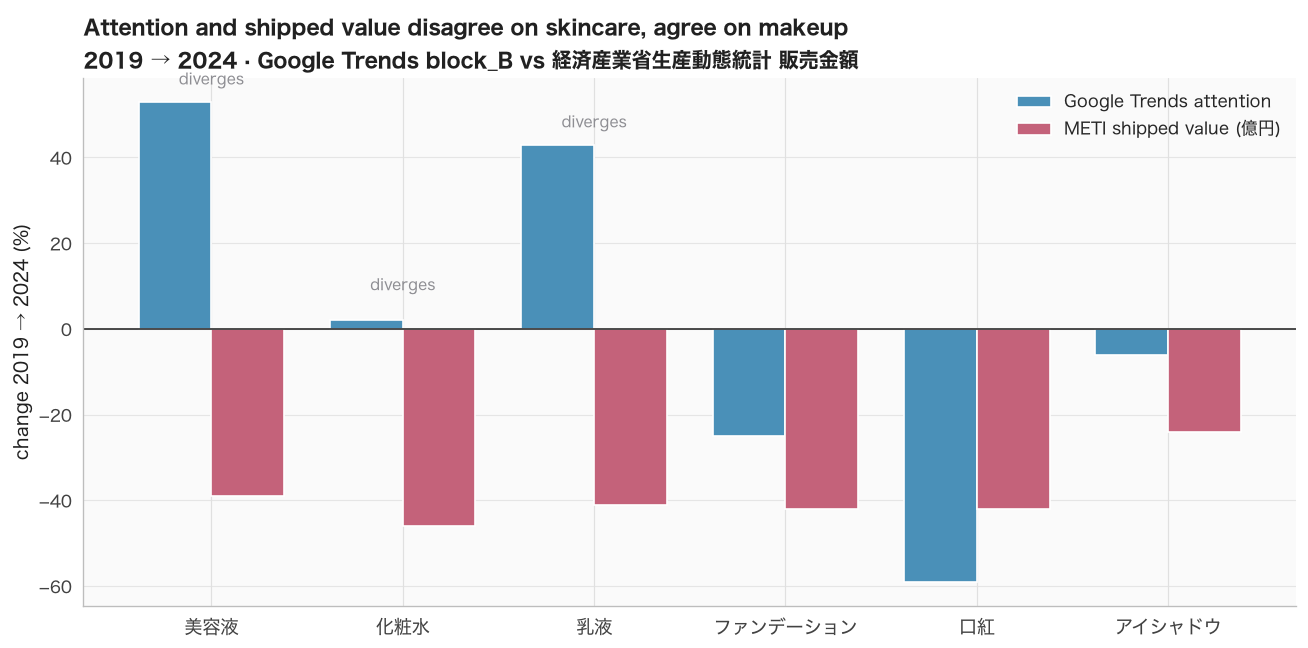

In [7]:
fig, ax = fig_ax(11, 5.5)
x = np.arange(len(comp))
w = 0.38
ax.bar(x - w/2, comp['attention Δ%'], w, color=C_ATT, label='Google Trends attention')
ax.bar(x + w/2, comp['value Δ%'],     w, color=C_VAL, label='METI shipped value (億円)')
ax.axhline(0, color='#2D2D2D', lw=1)
ax.set_xticks(x); ax.set_xticklabels(comp['category'], fontsize=11)
ax.set_ylabel('change 2019 → 2024 (%)')
ax.set_title('Attention and shipped value disagree on skincare, agree on makeup\n'
             '2019 → 2024 · Google Trends block_B vs 経済産業省生産動態統計 販売金額',
             fontsize=12, loc='left')
ax.legend(frameon=False, fontsize=10)
for i, r in comp.iterrows():
    if r['same sign'] == 'NO':
        ax.annotate('diverges', (i, max(r['attention Δ%'], 5) + 4), ha='center',
                    fontsize=9, color='#8E8E93')
tight(fig)
plt.show()

---
## 4. The category-level picture

The headline finding in NB05–NB07 is that 「化粧品」 search fell about a third
while 「スキンケア」 held flat. If that reflected demand, shipped value should show
the same shape.

In [8]:
SKIN = ['洗顔クリーム・フォーム','クレンジングクリーム','マッサージ・コールドクリーム',
        'モイスチャークリーム','乳液','化粧水','美容液','パック','男性皮膚用化粧品',
        'その他の皮膚用化粧品']
MAKE = [c for c in ['ファンデーション','おしろい','口紅','リップクリーム','ほほ紅',
                    'アイメークアップ','まゆ墨・まつ毛化粧料','つめ化粧料(除光液を含む)',
                    'その他の仕上用化粧品'] if c in meti.columns]

tot = meti[LEAF].sum(axis=1)
s, k = meti[SKIN].sum(axis=1), meti[MAKE].sum(axis=1)
summary = pd.DataFrame({'all cosmetics 億円': tot.round(0),
                        '皮膚用 skincare': s.round(0),
                        '仕上用 makeup': k.round(0),
                        'skincare:makeup': (s/k).round(2)})
print(summary.to_string())
print(f'''
Trends 「化粧品」   {trend.loc[Y0,"化粧品"]:.1f} → {trend.loc[Y1,"化粧品"]:.1f}  ({100*(trend.loc[Y1,"化粧品"]-trend.loc[Y0,"化粧品"])/trend.loc[Y0,"化粧品"]:+.0f}%)
METI all cosmetics {tot[Y0]:,.0f} → {tot[Y1]:,.0f} 億円  ({100*(tot[Y1]-tot[Y0])/tot[Y0]:+.0f}%)''')

      all cosmetics 億円  皮膚用 skincare  仕上用 makeup  skincare:makeup
year                                                             
2019           17611.0        8876.0      3730.0             2.38
2020           14784.0        7718.0      2457.0             3.14
2021           13529.0        6897.0      2183.0             3.16
2022           12654.0        5685.0      2428.0             2.34
2023           13025.0        5678.0      2703.0             2.10
2024           13745.0        6116.0      2872.0             2.13

Trends 「化粧品」   85.6 → 59.7  (-30%)
METI all cosmetics 17,611 → 13,745 億円  (-22%)


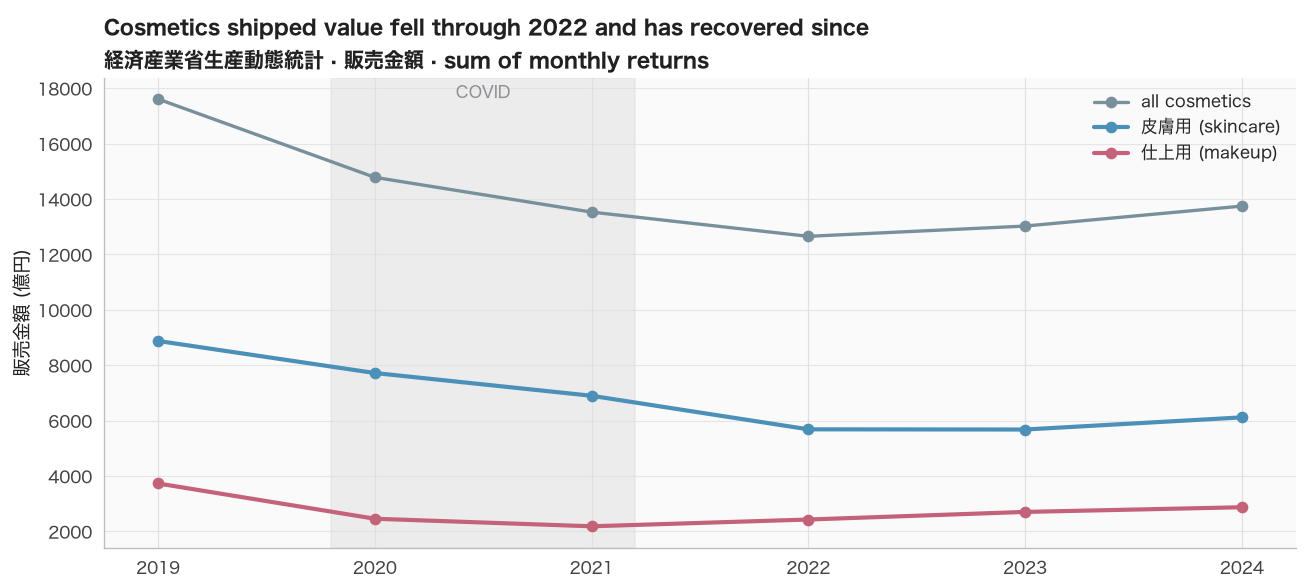

In [9]:
fig, ax = fig_ax(11, 5)
ax.plot(tot.index, tot.values, 'o-', color='#78909C', lw=2, label='all cosmetics')
ax.plot(s.index, s.values, 'o-', color=C_ATT, lw=2.5, label='皮膚用 (skincare)')
ax.plot(k.index, k.values, 'o-', color=C_VAL, lw=2.5, label='仕上用 (makeup)')
ax.axvspan(2019.8, 2021.2, color='#E0E0E0', alpha=.5, zorder=0)
ax.annotate('COVID', (2020.5, ax.get_ylim()[1]*0.96), ha='center', color='#8E8E93', fontsize=10)
ax.set_ylabel('販売金額 (億円)'); ax.set_xlabel('')
ax.set_title('Cosmetics shipped value fell through 2022 and has recovered since\n'
             '経済産業省生産動態統計 · 販売金額 · sum of monthly returns',
             fontsize=12, loc='left')
ax.legend(frameon=False, fontsize=10)
tight(fig)
plt.show()

---
## 5. Reading the divergence

Shipped value bottomed in 2022 and has risen for two years. Attention to skincare
actives has risen throughout. Three explanations are consistent with that, and
this notebook cannot separate them:

**a. The 2019 base is a peak, not a norm.** 2019 was the last full year of
inbound tourist buying. Purchases made in Japan by visitors sit in domestic
shipments; their collapse removes volume without any domestic consumer changing
behaviour.

**b. METI measures domestic shipments, not consumption.** It counts what
surveyed domestic establishments ship. It does not count imports. Korea overtook
France as Japan's largest cosmetics import source in 2024, and the K-Beauty
channel runs substantially through Qoo10 and direct import. A shift of
consumption toward imported skincare appears in this series as a *fall*.

**c. Respondent panel and scheme.** The survey covers establishments above a size
threshold and the item scheme was revised in 2021. 美容液 and 化粧水 both drop
about a third in 2022 while モイスチャークリーム and ファンデーション are flat that
year — an asymmetry more consistent with a reporting change than with demand.

Explanation (b) is the one that would reconcile the two series rather than
contradict them, and it is testable: add 貿易統計 HS 3304 imports to domestic
shipments to get apparent consumption. That is the next step, not this notebook.

**What can be said now:** the makeup decline is corroborated in money. The
skincare story is *not* corroborated, and until imports are added it should not
be presented as a demand finding — it remains an attention finding.

---
## 6. What 家計調査 can and cannot add

The household survey is the other half of caveat 12. It carries per-household
monthly spend, which is immune to the tourist and import problems above — it
measures Japanese households directly.

It cannot answer the main question. **家計調査 has no 美容液 line and no
sunscreen line**; both fall into 他の化粧品 (code 913). The category that moves
most in our attention data is exactly the one household spending does not track.

It does carry 化粧水, 乳液, 化粧クリーム, ファンデーション and 口紅 — enough to
cross-check the makeup half a second time, and to test whether 化粧水's flat
attention matches flat household spend. Left for a follow-up.

---
## Summary

| Claim from NB05–NB07 | Status after official statistics |
|---|---|
| Makeup attention fell | **corroborated** — ファンデーション −42%, 口紅 −42%, アイメークアップ −24% in shipped value |
| Skincare attention held flat while cosmetics fell | **not corroborated in money** — skincare lines fell further than makeup on shipped value |
| Ingredient search rose sharply | **out of scope** — no statistical series tracks ingredient-level demand |
| Skincare:makeup ratio | shipped value gives 2.38 → 2.13, i.e. *narrowing*, opposite to the platform SKU ratio |

The last row is the one to carry into NB07. The Rakuten SKU ratio and the METI
shipped-value ratio measure different things — shelf supply on one platform
versus domestic shipments across the market — and they move in opposite
directions over the same period.